# Pareto (multi-objective) selection: accuracy vs. program size

Second comparison notebook (docs/design/0003 phase 3), following the template from
[0001-tournament-vs-lexicase](0001-tournament-vs-lexicase.ipynb).

The second objective here is `LinearProgram.effective_instruction_count()` â€” the number of
instructions that actually contribute to the output, via the standard linear-GP "structural
intron" backward-liveness analysis (see `evolve/genome.py`). Programs stay a fixed length, but
how much of that length is *dead code* varies naturally, so this needed no genome representation
change â€” just a new way to measure an existing genome.

`ParetoSelection` (see `evolve/selection.py`) is **Pareto tournament** selection: draw `k`
candidates, return a random non-dominated one among them. This is a lightweight approximation of
full multi-objective GP (e.g. NSGA-II, which sorts the *entire* population into fronts every
generation) â€” worth keeping in mind when reading the results below.

In [1]:
import random
import statistics

import matplotlib.pyplot as plt

from evolve import (
    LinearCrossoverMutation,
    ParetoSelection,
    SymbolicRegressionFitness,
    TournamentSelection,
    evolve,
    random_program,
)

## The benchmark

Same fixed benchmark as every other notebook/job in this repo (docs/design/0003 "fixed benchmark
problems as an anchor").

In [2]:
TARGET = lambda x: x**4 - 3 * x**2 + 2
INPUTS = [i / 5 for i in range(-5, 6)]

POPULATION_SIZE = 60
NUM_INSTRUCTIONS = 12
NUM_REGISTERS = 4
GENERATIONS = 60
SEEDS = range(10)

fitness_evaluator = SymbolicRegressionFitness(target=TARGET, inputs=INPUTS)


def run_trial(selection, seed):
    rng = random.Random(seed)
    population = [
        random_program(NUM_INSTRUCTIONS, NUM_REGISTERS, num_inputs=1, rng=rng)
        for _ in range(POPULATION_SIZE)
    ]
    summaries = []
    final_population = evolve(
        population,
        fitness=fitness_evaluator,
        selection=selection,
        variation=LinearCrossoverMutation(mutation_rate=0.1),
        generations=GENERATIONS,
        on_generation=[summaries.append],
        rng=rng,
    )
    return summaries, final_population


strategies = {
    "tournament": lambda: TournamentSelection(k=3),
    "pareto": lambda: ParetoSelection(complexity=lambda p: p.effective_instruction_count(), k=3),
}

results = {name: [run_trial(factory(), seed) for seed in SEEDS] for name, factory in strategies.items()}

## Convergence comparison

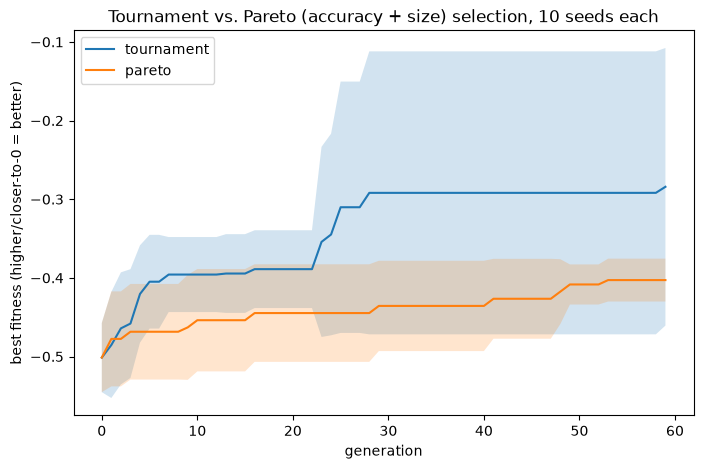

tournament: final best_fitness mean=-0.2842  mean effective program size=6.00 / 12
    pareto: final best_fitness mean=-0.4028  mean effective program size=2.00 / 12


In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

for name, trials in results.items():
    curves = [[s.best_fitness for s in summaries] for summaries, _final in trials]
    by_gen = list(zip(*curves))
    means = [statistics.fmean(gen_values) for gen_values in by_gen]
    stds = [statistics.pstdev(gen_values) for gen_values in by_gen]
    generations = range(len(means))
    ax.plot(generations, means, label=name)
    ax.fill_between(
        generations,
        [m - s for m, s in zip(means, stds)],
        [m + s for m, s in zip(means, stds)],
        alpha=0.2,
    )

ax.set_xlabel("generation")
ax.set_ylabel("best fitness (higher/closer-to-0 = better)")
ax.set_title(f"Tournament vs. Pareto (accuracy + size) selection, {len(SEEDS)} seeds each")
ax.legend()
plt.show()

for name, trials in results.items():
    final_fitness = [summaries[-1].best_fitness for summaries, _final in trials]
    mean_sizes = [
        statistics.fmean(p.effective_instruction_count() for p in final_population)
        for _summaries, final_population in trials
    ]
    print(
        f"{name:>10}: final best_fitness mean={statistics.fmean(final_fitness):.4f}  "
        f"mean effective program size={statistics.fmean(mean_sizes):.2f} / {NUM_INSTRUCTIONS}"
    )

Pareto selection reaches a noticeably **smaller** average program size than tournament selection
here â€” the effective-instruction-count objective is doing real work, not a no-op. But it comes at a
real cost: mean final fitness is worse than tournament's on this benchmark, not better. That's not
a bug in `ParetoSelection` â€” it's the actual tradeoff multi-objective selection makes explicit. A
population that's non-dominated on (accuracy, size) includes plenty of individuals that are small
*because* they're too simple to fit `x**4 - 3*x**2 + 2` well, and Pareto tournament selection has
no way to prefer "a bit more accurate" over "a bit smaller" â€” by construction, neither dominates
the other. Unlike lexicase selection in notebook 0001 (which improved on tournament's own
objective), this isn't a strictly-better replacement for tournament selection â€” it's a genuinely
different objective, and you get what you optimize for.

## What the tradeoff actually looks like

Every individual in one representative final population (seed 0), plotted as (effective program
size, mean fitness) â€” this is the closest thing to an actual Pareto front this lightweight,
tournament-local selection produces (a full NSGA-II-style implementation would sort the whole
population into fronts explicitly; this doesn't).

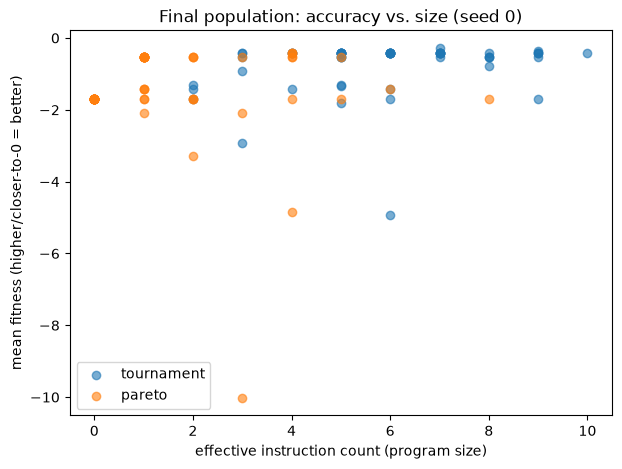

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))

for name, trials in results.items():
    _summaries, final_population = trials[0]  # seed 0
    sizes = [p.effective_instruction_count() for p in final_population]
    fits = [statistics.fmean(fitness_evaluator.evaluate(p)) for p in final_population]
    ax.scatter(sizes, fits, alpha=0.6, label=name)

ax.set_xlabel("effective instruction count (program size)")
ax.set_ylabel("mean fitness (higher/closer-to-0 = better)")
ax.set_title("Final population: accuracy vs. size (seed 0)")
ax.legend()
plt.show()

## Takeaways

- `effective_instruction_count()` gave a real, naturally-varying complexity measure without any
  change to the genome representation â€” dead code (structural introns) already varies even in a
  fixed-length linear GP genome, which is exactly what made this cheap to add.
- Pareto selection is not a drop-in upgrade the way lexicase was â€” it optimizes for a genuinely
  different thing (a *tradeoff curve*, not a single "better") and the numbers above show that
  honestly: smaller programs, at a real accuracy cost, on this benchmark.
- `ParetoSelection`'s `complexity` argument is injected, not assumed â€” the strategy itself stays
  genome-generic; only the call site couples it to `LinearProgram.effective_instruction_count`.
  Any `Genome -> float` complexity/cost measure plugs in the same way.
- Next per docs/design/0003's roadmap: a second representation (tree or stack-based GP) â€” the
  first real test of whether `Population`/`SelectionStrategy`/`VariationStrategy` actually stay
  generic across genome types, not just across selection strategies on the same one.